# 12 — Root-Cause Analysis with a Structural Equation Model

**Question (use case 2).** *What are the causal drivers of a candidate being hired, and how do they mediate the effect of agency sourcing?* We answer it with the **structural-equation-model (SEM) root-cause-analysis** approach of Qafari & van der Aalst (*Root Cause Analysis in Process Mining Using Structural Equation Models*, BPM 2020 — [vdaalst p1164](https://www.vdaalst.rwth-aachen.de/publications/p1164.pdf)).

**The recipe (paper-aligned):**
1. Turn the event log into a **case-level feature table** of process characteristics (mediators) + the outcome.
2. **Hypothesise a causal graph (DAG)** from domain knowledge over these features.
3. **Falsify** it: test the conditional-independence (CI) constraints the DAG implies; compare against a data-driven skeleton (PC algorithm). Refine.
4. Fit the **SEM** (`semopy`) → standardised **path coefficients** + global **fit indices** (χ², CFI, RMSEA).
5. Fit a **structural causal model** (`dowhy.gcm`) on the same DAG → **arrow strengths** and **intrinsic causal influence**, which *rank the root causes* of the target KPI.

**Unit:** the candidate case (`Case_id`, n ≈ 279k). **Target KPI:** `hired`.

> Environment: `pm_causal`. This notebook is *explanatory* (mechanism / attribution), complementing the *treatment-effect* estimation in `11_causal_agency.ipynb`.

In [1]:
import warnings, numpy as np, pandas as pd
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt, seaborn as sns, networkx as nx
sns.set_theme(style='whitegrid', context='notebook')
RNG = 42; np.random.seed(RNG)
from pathlib import Path
DATA = Path('data/event_log_consolidated.csv'); FIGS = Path('figs'); FIGS.mkdir(exist_ok=True)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
print('libs ready')

libs ready


## 1. Case-level feature table (process characteristics)

We derive, per candidate case, a compact set of **process throughput features** that can plausibly sit on the causal path from *how the case was handled* to *whether it ended in a hire*:

| feature | meaning | role |
|---|---|---|
| `agency` | candidate sourced via external agency | exogenous cause |
| `n_reschedules` | # `Schedule Interview` events | scheduling friction / rework |
| `n_interviews` | # interview activities (recruiter/manager/…) | evaluation intensity |
| `n_stages` | # distinct activities reached | progression depth |
| `dur_days` | case span in days | throughput time |
| `hired` | hired (0/1) | **target KPI** |

In [2]:
usecols=['Recruiting Agency','Case_id','hired','Completed By','Step','timestamp']
df=pd.read_csv(DATA, usecols=usecols, low_memory=False)
df['timestamp']=pd.to_datetime(df['timestamp'], errors='coerce')
df=df.dropna(subset=['timestamp','Case_id']).sort_values('timestamp')
INTERVIEW={'Recruiter Interview','Manager Interview','Additional Interview','Workday Interview'}
df['is_int']=df['Step'].isin(INTERVIEW)
df['is_resched']=df['Step'].eq('Schedule Interview')
df['agency_ev']=(df['Recruiting Agency'].notna() & (df['Recruiting Agency'].astype(str).str.strip()!='')).astype(int)

g=df.groupby('Case_id', sort=False)
case=g.agg(n_events=('Step','size'), n_interviews=('is_int','sum'),
          n_reschedules=('is_resched','sum'), n_stages=('Step','nunique'),
          n_resources=('Completed By','nunique'),
          ts_min=('timestamp','min'), ts_max=('timestamp','max'),
          hired=('hired','max'), agency=('agency_ev','max'))
case['dur_days']=(case['ts_max']-case['ts_min']).dt.total_seconds()/86400
FEATS=['agency','n_reschedules','n_interviews','n_stages','dur_days','hired']
case=case[FEATS].astype(float)
print(f'{len(case):,} cases | hire rate {case.hired.mean():.3f} | agency rate {case.agency.mean():.3f}')
print(case.describe().round(3).T[['mean','std','min','50%','max']])

279,458 cases | hire rate 0.020 | agency rate 0.010
                mean    std   min   50%       max
agency         0.010  0.098 0.000 0.000     1.000
n_reschedules  0.146  0.534 0.000 0.000    10.000
n_interviews   0.145  0.528 0.000 0.000    10.000
n_stages       3.413  2.900 1.000 2.000    27.000
dur_days      17.430 49.617 0.000 0.000 1,156.290
hired          0.020  0.140 0.000 0.000     1.000


### Correlation structure

A quick standardized correlation heatmap motivates the graph: which throughput features co-move with `hired`.

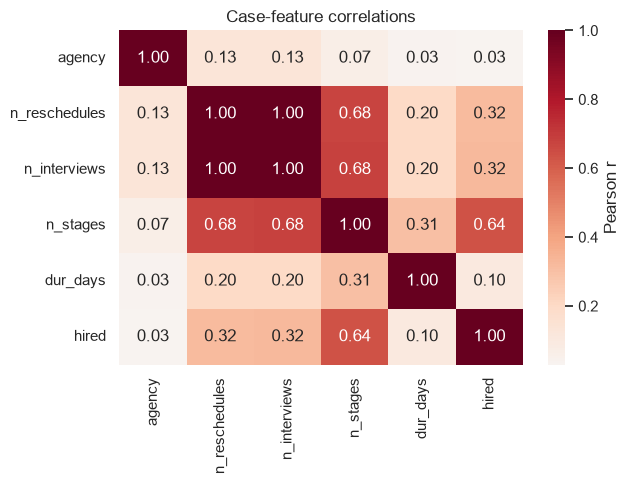

In [3]:
from scipy.stats import zscore
Z=case.apply(zscore)            # standardised features for SEM / CI tests / path coeffs
fig,ax=plt.subplots(figsize=(6.5,5))
sns.heatmap(case.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label':'Pearson r'})
ax.set_title('Case-feature correlations')
plt.tight_layout(); plt.savefig(FIGS/'causal_rca_corr.png', bbox_inches='tight', dpi=120); plt.show()

## 2. Hypothesised causal graph (DAG)

Domain reasoning over the recruiting funnel *Start → Screen → Interview → Offer → Hire*:

- Agency sourcing changes **how** a candidate is handled → it affects scheduling rework, interview intensity and progression depth.
- Scheduling friction feeds more interviews; interviews drive how deep the case progresses; depth, intensity and rework all inflate **duration**.
- Finally, progression depth, interview intensity, duration and the agency channel itself drive the **hire** decision.

$$	ext{agency}	o\{	ext{n\_reschedules, n\_interviews, n\_stages, hired}\},\;
	ext{n\_reschedules}	o\{	ext{n\_interviews, dur\_days}\},\;
	ext{n\_interviews}	o\{	ext{n\_stages, dur\_days, hired}\},\;
	ext{n\_stages}	o\{	ext{dur\_days, hired}\},\; 	ext{dur\_days}	o 	ext{hired}$$

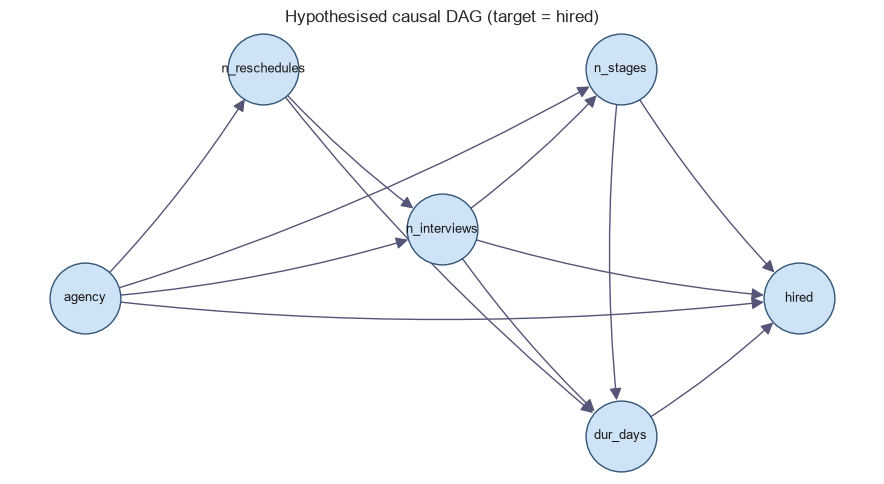

In [4]:
EDGES=[('agency','n_reschedules'),('agency','n_interviews'),('agency','n_stages'),('agency','hired'),
       ('n_reschedules','n_interviews'),('n_reschedules','dur_days'),
       ('n_interviews','n_stages'),('n_interviews','dur_days'),('n_interviews','hired'),
       ('n_stages','dur_days'),('n_stages','hired'),
       ('dur_days','hired')]
G=nx.DiGraph(EDGES)
assert nx.is_directed_acyclic_graph(G), 'graph must be a DAG'
pos={'agency':(0,1),'n_reschedules':(1,2),'n_interviews':(2,1.3),
     'n_stages':(3,2),'dur_days':(3,0.4),'hired':(4,1)}
fig,ax=plt.subplots(figsize=(9,5))
nx.draw_networkx_nodes(G,pos,node_size=2600,node_color='#cfe3f7',edgecolors='#357',ax=ax)
nx.draw_networkx_labels(G,pos,font_size=9,ax=ax)
nx.draw_networkx_edges(G,pos,arrowsize=18,edge_color='#557',node_size=2600,
                       connectionstyle='arc3,rad=0.06',ax=ax)
ax.set_title('Hypothesised causal DAG (target = hired)'); ax.axis('off')
plt.tight_layout(); plt.savefig(FIGS/'causal_rca_dag.png', bbox_inches='tight', dpi=120); plt.show()

## 3. Falsification — implied conditional independencies + PC skeleton

Every missing edge in the DAG implies a testable **conditional independence**. Using a Fisher-Z partial-correlation test on the standardized data, a small p-value (< 0.05) means the implied independence is **violated** — evidence of a missing edge. We test the constraints for the two node pairs the DAG leaves *unconnected given their parents*, then contrast with a **PC-algorithm** skeleton (data-driven discovery) to see whether the theory graph is broadly compatible.

In [5]:
from causallearn.utils.cit import CIT
cols=list(case.columns); idx={c:i for i,c in enumerate(cols)}
cit=CIT(Z[cols].values, 'fisherz')
def ci_test(x,y,cond):
    return cit(idx[x], idx[y], [idx[c] for c in cond])
# Implied independencies (given parents that d-separate the pair):
tests=[('agency','dur_days',['n_reschedules','n_interviews','n_stages']),
       ('n_reschedules','hired',['agency','n_interviews','n_stages','dur_days']),
       ('n_reschedules','n_stages',['agency','n_interviews'])]
rows=[]
for x,y,cnd in tests:
    p=ci_test(x,y,cnd)
    rows.append((f'{x} ⟂ {y} | {", ".join(cnd)}', p, 'holds (ok)' if p>0.05 else 'VIOLATED -> missing edge?'))
ci_df=pd.DataFrame(rows, columns=['implied independence','p_value','verdict'])
print(ci_df.to_string(index=False))

                                            implied independence  p_value                   verdict
       agency ⟂ dur_days | n_reschedules, n_interviews, n_stages    0.000 VIOLATED -> missing edge?
n_reschedules ⟂ hired | agency, n_interviews, n_stages, dur_days    0.000 VIOLATED -> missing edge?
                 n_reschedules ⟂ n_stages | agency, n_interviews    0.369                holds (ok)


In [6]:
# Data-driven skeleton via PC (subsample for speed) to compare with the hypothesised graph
from causallearn.search.ConstraintBased.PC import pc
sub=Z[cols].sample(n=min(20000,len(Z)), random_state=RNG).values
cg=pc(sub, alpha=0.01, indep_test='fisherz', show_progress=False)
adj=cg.G.graph  # i<->j entries encode edge marks
pc_edges=set()
for i in range(len(cols)):
    for j in range(i+1,len(cols)):
        if adj[i][j]!=0 or adj[j][i]!=0:
            pc_edges.add(tuple(sorted((cols[i],cols[j]))))
hyp_edges={tuple(sorted(e)) for e in EDGES}
print('hypothesised (undirected) edges :', len(hyp_edges))
print('PC-discovered edges              :', len(pc_edges))
print('\nin PC but NOT hypothesised (candidate additions):')
for e in sorted(pc_edges-hyp_edges): print('   ', e)
print('in hypothesis but NOT in PC (candidate removals):')
for e in sorted(hyp_edges-pc_edges): print('   ', e)

hypothesised (undirected) edges : 12
PC-discovered edges              : 9

in PC but NOT hypothesised (candidate additions):
    ('hired', 'n_reschedules')
    ('n_reschedules', 'n_stages')
in hypothesis but NOT in PC (candidate removals):
    ('agency', 'hired')
    ('agency', 'n_reschedules')
    ('dur_days', 'n_interviews')
    ('dur_days', 'n_reschedules')
    ('hired', 'n_interviews')


## 4. Structural Equation Model (`semopy`)

We fit the DAG as an SEM on standardized data. The output gives **standardized path coefficients** (each edge's direct effect, in SD units) and **global fit indices** — χ²/df, CFI, RMSEA — quantifying how well the hypothesised structure reproduces the observed covariance matrix.

In [7]:
import semopy
desc='''
n_reschedules ~ agency
n_interviews ~ agency + n_reschedules
n_stages ~ agency + n_interviews
dur_days ~ n_reschedules + n_interviews + n_stages
hired ~ agency + n_interviews + n_stages + dur_days
'''
sem=semopy.Model(desc); sem.fit(Z)
est=sem.inspect(std_est=True)
paths=est[est['op']=='~'][['lval','op','rval','Est. Std','p-value']].copy()
paths.columns=['outcome','op','predictor','std_coef','p_value']
paths['std_coef']=paths['std_coef'].astype(float)
print(paths.sort_values('std_coef', key=abs, ascending=False).to_string(index=False))
try:
    stats=semopy.calc_stats(sem).T
    print('\nGlobal fit:'); print(stats.loc[['chi2','chi2 p-value','CFI','TLI','RMSEA']].round(4))
except Exception as e:
    print('fit-stat note:', e)

      outcome op     predictor  std_coef  p_value
 n_interviews  ~ n_reschedules     0.996    0.000
        hired  ~      n_stages     0.808    0.000
     n_stages  ~  n_interviews     0.680    0.000
     dur_days  ~      n_stages     0.311    0.000
     dur_days  ~ n_reschedules    -0.229    0.000
     dur_days  ~  n_interviews     0.221    0.000
        hired  ~  n_interviews    -0.204    0.000
n_reschedules  ~        agency     0.128    0.000
        hired  ~      dur_days    -0.103    0.000
     n_stages  ~        agency    -0.018    0.000
        hired  ~        agency     0.003    0.046
 n_interviews  ~        agency     0.002    0.000

Global fit:
               Value
chi2         392.993
chi2 p-value   0.000
CFI            1.000
TLI            0.999
RMSEA          0.019


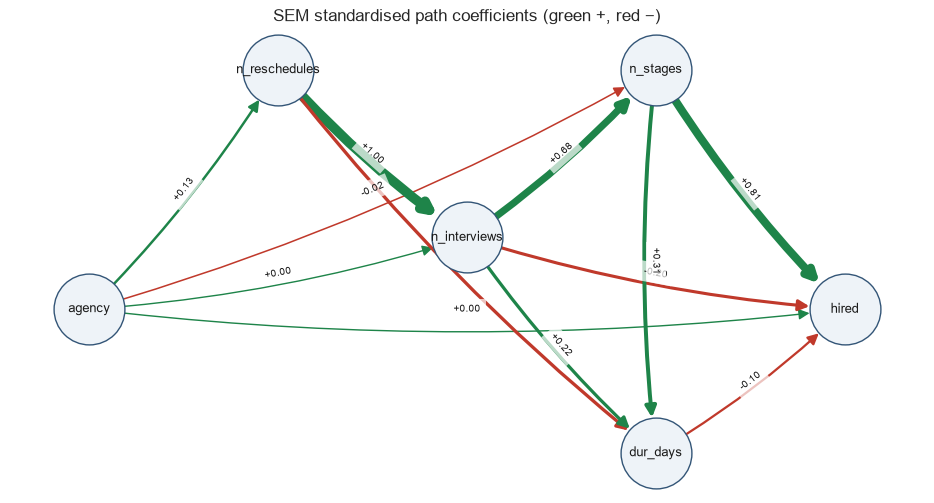

In [8]:
# Path diagram coloured by standardised coefficient (only edges toward the funnel)
fig,ax=plt.subplots(figsize=(9.5,5.2))
ec, ew, elabels = [], [], {}
for u,v in G.edges():
    r=paths[(paths.outcome==v)&(paths.predictor==u)]
    b=float(r['std_coef'].iloc[0]) if len(r) else 0.0
    ec.append('#c0392b' if b<0 else '#1e8449'); ew.append(1+6*abs(b)); elabels[(u,v)]=f'{b:+.2f}'
nx.draw_networkx_nodes(G,pos,node_size=2600,node_color='#eef3f8',edgecolors='#357',ax=ax)
nx.draw_networkx_labels(G,pos,font_size=9,ax=ax)
nx.draw_networkx_edges(G,pos,arrowsize=16,edge_color=ec,width=ew,node_size=2600,
                       connectionstyle='arc3,rad=0.06',ax=ax)
nx.draw_networkx_edge_labels(G,pos,edge_labels=elabels,font_size=7,label_pos=0.5,
                             bbox=dict(fc='white',ec='none',alpha=.7),ax=ax)
ax.set_title('SEM standardised path coefficients (green +, red −)'); ax.axis('off')
plt.tight_layout(); plt.savefig(FIGS/'causal_rca_sem_paths.png', bbox_inches='tight', dpi=120); plt.show()

## 5. Root-cause ranking (`dowhy.gcm`)

On the same DAG we fit a structural causal model and quantify, for the target `hired`:
- **arrow strength** — how much each *direct parent* edge contributes to the variance of `hired` (remove-the-edge importance);
- **intrinsic causal influence (ICC)** — a Shapley-based attribution of `hired`'s variance to *each upstream node's own noise*, i.e. the genuine **root causes** (not just proxies of their parents).

ICC is the paper's notion of ranked root causes. We fit on a random subsample for tractability.

In [9]:
import dowhy.gcm as gcm
data_g=case.sample(n=min(8000,len(case)), random_state=RNG).reset_index(drop=True)
scm=gcm.StructuralCausalModel(G)
gcm.auto.assign_causal_mechanisms(scm, data_g)
gcm.fit(scm, data_g)

arrows=gcm.arrow_strength(scm, target_node='hired')
arr=pd.Series({k[0]:v for k,v in arrows.items()}).sort_values(ascending=False)
print('Arrow strength into hired (direct parents):'); print(arr.round(4).to_string())

icc=gcm.intrinsic_causal_influence(scm, target_node='hired', num_samples_randomization=800)
icc=pd.Series(icc); icc=(icc/icc.abs().sum()).sort_values(key=abs, ascending=False)
print('\nIntrinsic causal influence on hired (share of explained variation):')
print((icc*100).round(1).astype(str).add(' %').to_string())

Fitting causal models:   0%|          | 0/6 [00:00<?, ?it/s]

Fitting causal mechanism of node agency:   0%|          | 0/6 [00:00<?, ?it/s]

Fitting causal mechanism of node n_reschedules:   0%|          | 0/6 [00:00<?, ?it/s]

Fitting causal mechanism of node n_reschedules:  33%|███▎      | 2/6 [00:01<00:03,  1.23it/s]

Fitting causal mechanism of node n_interviews:  33%|███▎      | 2/6 [00:01<00:03,  1.23it/s] 

...

Evaluating set functions...:   0%|          | 0/53 [00:00<?, ?it/s]

Evaluating set functions...:  60%|██████    | 32/53 [00:13<00:08,  2.41it/s]

Evaluating set functions...:  91%|█████████ | 48/53 [00:27<00:03,  1.65it/s]

Evaluating set functions...: 100%|██████████| 53/53 [00:27<00:00,  1.94it/s]


Intrinsic causal influence on hired (share of explained variation):
n_stages         89.9 %
hired             9.4 %
n_reschedules     0.4 %
dur_days          0.1 %
agency           -0.1 %
n_interviews     -0.0 %


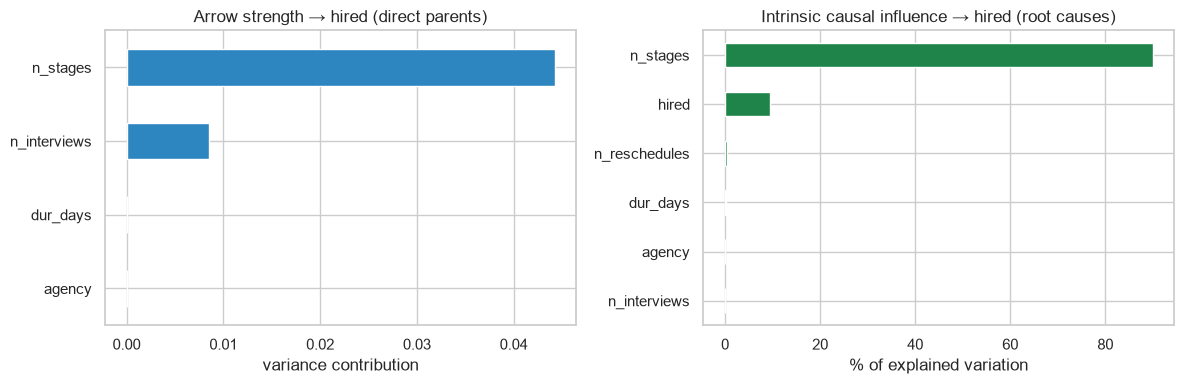

In [10]:
fig,ax=plt.subplots(1,2,figsize=(12,4))
arr.sort_values().plot.barh(ax=ax[0], color='#2e86c1')
ax[0].set_title('Arrow strength → hired (direct parents)'); ax[0].set_xlabel('variance contribution')
icc_sorted=icc.reindex(icc.abs().sort_values().index)
icc_sorted.mul(100).plot.barh(ax=ax[1], color=np.where(icc_sorted<0,'#c0392b','#1e8449'))
ax[1].set_title('Intrinsic causal influence → hired (root causes)'); ax[1].set_xlabel('% of explained variation')
plt.tight_layout(); plt.savefig(FIGS/'causal_rca_rootcause.png', bbox_inches='tight', dpi=120); plt.show()

## 6. Summary

- **§3 falsification** reports which implied independencies hold and how the theory DAG compares with the PC-discovered skeleton — the basis for any structural refinement.
- **§4 SEM** gives the standardized direct effects along each path plus global fit indices; the largest-magnitude coefficients into `hired` are the strongest *direct* drivers, and the `agency → mediators` coefficients show how the sourcing channel propagates through the funnel.
- **§5 GCM** ranks the **root causes** of hiring by intrinsic causal influence — the variables whose own variation, propagated through the graph, explains the most variation in the hire outcome.

Together this triangulates *why* candidates get hired and locates where in the process the agency channel exerts its influence — the mediation counterpart to the treatment-effect estimate in notebook 11. Read the printed coefficients/rankings into the thesis narrative.

*Caveats:* mediators are zero-inflated counts modelled linearly (SEM simplification); `hired` is a rare binary outcome treated as continuous for path estimation; the DAG is domain-hypothesised and only partially falsified — residual mis-specification and unobserved confounding (e.g. candidate quality) cannot be excluded.